<a href="https://colab.research.google.com/github/harshal3141592/tmrwRFWstockpredictor/blob/main/SharePrice_Prediction_RFA_dynamic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
nifty50 = yf.Ticker("^NSEI")
nifty50 = nifty50.history(period='max')
nifty50

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,0.0,0.0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,0.0,0.0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,0.0,0.0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,0.0,0.0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-09-07 00:00:00+05:30,23883.150391,23890.000000,23737.900391,23779.150391,205900,0.0,0.0
2026-09-08 00:00:00+05:30,23743.099609,23758.949219,23623.099609,23635.099609,230100,0.0,0.0
2026-09-09 00:00:00+05:30,23522.050781,23571.550781,23431.500000,23431.500000,352900,0.0,0.0


# Our first step involves using yfinance library to get information about the specific day when market was open.

We have chosen Nifty50, with ticker _NSEI_.

We want information ranging from the day the data was archived electronically till date, therefore we set the time period history at "MAX".

The table includes the date, "Open", "High", "Low", "Close", "Volume","Dividends" and Stock Splits". (OHLCV)

In [2]:
nifty50.index

DatetimeIndex(['2007-09-17 00:00:00+05:30', '2007-09-18 00:00:00+05:30',
               '2007-09-19 00:00:00+05:30', '2007-09-20 00:00:00+05:30',
               '2007-09-21 00:00:00+05:30', '2007-09-24 00:00:00+05:30',
               '2007-09-25 00:00:00+05:30', '2007-09-26 00:00:00+05:30',
               '2007-09-27 00:00:00+05:30', '2007-09-28 00:00:00+05:30',
               ...
               '2026-08-31 00:00:00+05:30', '2026-09-01 00:00:00+05:30',
               '2026-09-02 00:00:00+05:30', '2026-09-03 00:00:00+05:30',
               '2026-09-04 00:00:00+05:30', '2026-09-07 00:00:00+05:30',
               '2026-09-08 00:00:00+05:30', '2026-09-09 00:00:00+05:30',
               '2026-09-10 00:00:00+05:30', '2026-09-11 00:00:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', name='Date', length=4659, freq=None)

The Indian markets' historical data, ranging from 2007 to 2026, is considered relatively recent and reliable due to the transition to electronic data collection and storage, which has minimized errors and inconsistencies. To ensure data integrity, it is essential to verify the data source and its credibility, conduct a preliminary check for missing values or inconsistencies, and cross-validate the data with other reputable sources, if available. By adopting this rigorous approach, we can further enhance our confidence in the accuracy and reliability of the data.

<Axes: xlabel='Date'>

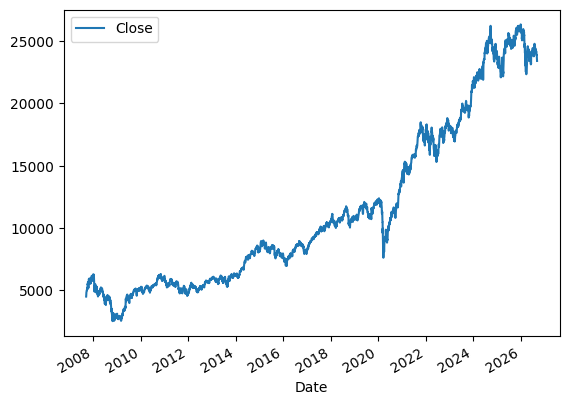

In [3]:
nifty50.plot.line(y="Close", use_index=True)

In [4]:
if 'Dividends' in nifty50.columns:
    del nifty50['Dividends']
if 'Stock Splits' in nifty50.columns:
    del nifty50['Stock Splits']

ML can be useful in predicting events that have several datapoints to conclude the possibility, and it can be quite accurate at predicting the absolute price of a stock,but it will be of no use, if you can't observe or analyze the directionality of the stock i.e., when the stock price will go up and when it will go down. In order to achieve this objective, our model should be able to detect days when market closed, whether it was porfitable to buy the stock on those days and after a buy those stock prices went up.

For this, we will shift one datapoint from the closing point in a new column called tomorrow in which the last entry will be blank(NaN)

TL:DR
1. Detect days when the market closed
2. Identify profitable buy days
3. Analyze post-buy stock price movements to confirm upward trends

In [5]:
#adding Tomorrow's column, where the data is shift a day back using the pandas shift method.
nifty50["Tomorrow"] = nifty50["Close"].shift(-1)
nifty50

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195
...,...,...,...,...,...,...
2026-09-07 00:00:00+05:30,23883.150391,23890.000000,23737.900391,23779.150391,205900,23635.099609
2026-09-08 00:00:00+05:30,23743.099609,23758.949219,23623.099609,23635.099609,230100,23431.500000
2026-09-09 00:00:00+05:30,23522.050781,23571.550781,23431.500000,23431.500000,352900,23477.800781


Now to point the directionality of share point, we will create a new column "Target" and assign a binary switch for the direction. "1" suggesting the nifty point going up and "0" suggesting the points is going down. The column will see whether the datapoint on column Tomorrow is greater than or less than the datapoint present at column Close.

In [6]:
nifty50["Target"] = (nifty50["Tomorrow"] > nifty50["Close"]).astype(int)
nifty50
#binary indication whether the target was achieved(1) or not(0)

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195,1
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098,1
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805,1
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805,1
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195,1
...,...,...,...,...,...,...,...
2026-09-07 00:00:00+05:30,23883.150391,23890.000000,23737.900391,23779.150391,205900,23635.099609,0
2026-09-08 00:00:00+05:30,23743.099609,23758.949219,23623.099609,23635.099609,230100,23431.500000,0
2026-09-09 00:00:00+05:30,23522.050781,23571.550781,23431.500000,23431.500000,352900,23477.800781,1


Now, we can run a random forest classifier from scikit learn lib.

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = nifty50.iloc[:-100]
test = nifty50.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [8]:
nifty50['Volume'].dtype

dtype('int64')

In [9]:
import pandas as pd
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.43243243243243246

<Axes: xlabel='Date'>

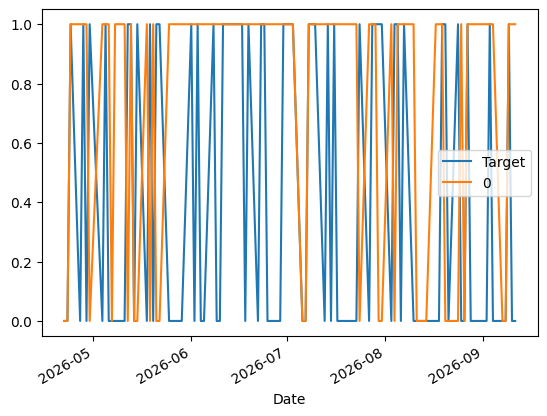

In [10]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [11]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

Training the model once on a single train/test split risks overfitting to one slice of market history, and if we're not careful, the model could accidentally "see" future data during training. This problem is often known as **lookahead bias**.

To avoid this, we use a walk-forward backtest instead: the model is retrained repeatedly on an expanding window of history and tested only on the chunk of days immediately after that window. Concretely, `start=2500` means the model's first training window covers roughly the first 10 years of data, and `step=250` means it is then re-trained and re-tested on the next ~250 trading days (about a year) at a time, moving forward until we run out of data. This mimics how the model would actually have been used in real time, i.e. trained only on what was known up to that point.

In [12]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [13]:
baseline_predictions = backtest(nifty50, model, predictors)

In [14]:
baseline_predictions["Predictions"].value_counts()

,count
Predictions,
1,1212
0,947


In [15]:
precision_score(baseline_predictions["Target"], baseline_predictions["Predictions"])

0.5288778877887789

In [16]:
from IPython.display import Markdown, display

precision_baseline = precision_score(baseline_predictions["Target"], baseline_predictions["Predictions"])
base_rate = baseline_predictions["Target"].value_counts(normalize=True).get(1, 0)
gap = precision_baseline - base_rate

if gap > 0.03:
    insight = "meaningfully beats the base rate, suggesting the model has picked up a genuine directional signal."
elif gap < -0.03:
    insight = "falls below the base rate, suggesting these features add noise rather than signal."
else:
    insight = "is nearly identical to the base rate, indicating the model provides little real predictive advantage over simply guessing the majority class."

display(Markdown(f"""
### Model Evaluation
- **Precision:** {precision_baseline:.1%}
- **Base Rate:** {base_rate:.1%} up-days
- **Insight:** The model's precision {insight}
"""))



### Model Evaluation
- **Precision:** 52.9%
- **Base Rate:** 53.7% up-days
- **Insight:** The model's precision is nearly identical to the base rate, indicating the model provides little real predictive advantage over simply guessing the majority class.


In [17]:
baseline_predictions["Target"].value_counts() / baseline_predictions.shape[0]

,count
Target,
1,0.537286
0,0.462714


Since raw price/volume levels gave us little edge, we engineer features that capture *relative* momentum instead of absolute price. For each horizon (2, 5, 60, 250, and 1000 trading days. It covers roughly a trading week, week-and-a-half, quarter, year, and 4 years):

- **Close_Ratio_{horizon}**: today's close divided by the average close over that horizon, capturing whether the stock is currently trading above or below its recent average.
- **Trend_{horizon}**: the number of "up" days in that horizon, capturing recent momentum.

Using multiple horizons together lets the model weigh short-term momentum against longer-term trend, rather than relying on any single time window.

In [18]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = nifty50.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    nifty50[ratio_column] = nifty50["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    nifty50[trend_column] = nifty50.shift(1).rolling(horizon).sum()["Target"]

    new_predictors+= [ratio_column, trend_column]

In [19]:
nifty50 = nifty50.dropna(subset=nifty50.columns[nifty50.columns != "Tomorrow"])
nifty50

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2011-10-13 00:00:00+05:30,5130.799805,5136.950195,5067.649902,5077.850098,0,5132.299805,1,0.997883,1.0,1.014789,3.0,0.992330,23.0,0.911365,111.0,1.042939,510.0
2011-10-14 00:00:00+05:30,5057.350098,5141.399902,5056.600098,5132.299805,0,5118.250000,0,1.005333,1.0,1.015754,3.0,1.004393,24.0,0.921801,111.0,1.053995,510.0
2011-10-17 00:00:00+05:30,5156.200195,5160.200195,5084.500000,5118.250000,0,5037.500000,0,0.998629,1.0,1.007444,2.0,1.003264,23.0,0.919921,111.0,1.051026,509.0
2011-10-18 00:00:00+05:30,5049.450195,5057.500000,5011.049805,5037.500000,0,5139.149902,1,0.992049,0.0,0.989091,2.0,0.989147,23.0,0.906187,110.0,1.034383,508.0
2011-10-19 00:00:00+05:30,5080.450195,5148.049805,5075.299805,5139.149902,0,5091.899902,0,1.009989,1.0,1.007477,2.0,1.010438,24.0,0.925163,111.0,1.055190,508.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-07 00:00:00+05:30,23883.150391,23890.000000,23737.900391,23779.150391,205900,23635.099609,0,0.997513,1.0,0.994772,1.0,0.983892,29.0,0.960937,126.0,1.068085,531.0
2026-09-08 00:00:00+05:30,23743.099609,23758.949219,23623.099609,23635.099609,230100,23431.500000,0,0.996962,0.0,0.992239,1.0,0.978079,28.0,0.955282,125.0,1.061335,531.0
2026-09-09 00:00:00+05:30,23522.050781,23571.550781,23431.500000,23431.500000,352900,23477.800781,1,0.995674,0.0,0.987697,1.0,0.970027,27.0,0.947253,124.0,1.051911,531.0


Instead of using the model's default 50% threshold to call a day "buy," we raise it to 60%. This is a precision/recall trade-off: a lower threshold generates more buy signals but includes more false positives, while a higher threshold produces fewer, higher-confidence signals. Since acting on a false "buy" signal is more costly in real trading than missing a genuine one, we deliberately favor precision over volume of signals here.

In [20]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [21]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [22]:
final_predictions = backtest(nifty50, model, new_predictors)

In [23]:
final_predictions["Predictions"].value_counts()

,count
Predictions,
0.0,1024
1.0,135


In [24]:
precision_score(final_predictions["Target"], final_predictions["Predictions"])

0.562962962962963

In [25]:
from IPython.display import Markdown, display

baseline_precision = precision_score(baseline_predictions["Target"], baseline_predictions["Predictions"])
baseline_rate = baseline_predictions["Target"].value_counts(normalize=True).get(1, 0)
baseline_signals = int(baseline_predictions["Predictions"].sum())
baseline_total = baseline_predictions.shape[0]

final_precision = precision_score(final_predictions["Target"], final_predictions["Predictions"])
final_signals = int(final_predictions["Predictions"].sum())
final_total = final_predictions.shape[0]

gap = final_precision - baseline_precision
if gap > 0.03:
    comparison = "meaningfully beats the baseline model"
elif gap < -0.03:
    comparison = "actually underperforms the baseline model"
else:
    comparison = "performs about the same as the baseline model"

signal_note = ("firing far fewer signals in the process \u2014 it is more selective, not necessarily smarter across all conditions."
               if final_signals < baseline_signals else
               "while also firing more signals in the process.")

display(Markdown(f"""
## Results & Limitations

Summary of precision achieved against the {baseline_rate:.1%} "always predict up" baseline:

| Model | Precision | Signals fired |
|---|---|---|
| Baseline (raw features) | {baseline_precision:.1%} | {baseline_signals} / {baseline_total} |
| Engineered features + 0.6 threshold | {final_precision:.1%} | {final_signals} / {final_total} |

The engineered-feature model **{comparison}**, {signal_note}

A few limitations worth flagging regardless of the exact numbers above:

- **No transaction costs or slippage are modeled:** a real strategy would need each "buy" to clear brokerage and impact costs, not just beat the baseline.
- **No position sizing or risk management:** the model outputs a direction, not how much capital to risk.
- **Single-index scope:** trained only on Nifty50; performance may not generalize to individual stocks or other indices.
- **No macro or news features:** the model only sees price/volume history, ignoring earnings, budget announcements, or global market moves.
- **Threshold chosen manually, not tuned via cross-validation** \u2014 0.6 was a reasonable starting point, not an optimized value.
- **Small sample sizes** in either model mean these precision estimates carry meaningful uncertainty and should be validated on more test data before drawing strong conclusions.
"""))



## Results & Limitations

Summary of precision achieved against the 53.7% "always predict up" baseline:

| Model | Precision | Signals fired |
|---|---|---|
| Baseline (raw features) | 52.9% | 1212 / 2159 |
| Engineered features + 0.6 threshold | 56.3% | 135 / 1159 |

The engineered-feature model **meaningfully beats the baseline model**, firing far fewer signals in the process — it is more selective, not necessarily smarter across all conditions.

A few limitations worth flagging regardless of the exact numbers above:

- **No transaction costs or slippage are modeled:** a real strategy would need each "buy" to clear brokerage and impact costs, not just beat the baseline.
- **No position sizing or risk management:** the model outputs a direction, not how much capital to risk.
- **Single-index scope:** trained only on Nifty50; performance may not generalize to individual stocks or other indices.
- **No macro or news features:** the model only sees price/volume history, ignoring earnings, budget announcements, or global market moves.
- **Threshold chosen manually, not tuned via cross-validation** — 0.6 was a reasonable starting point, not an optimized value.
- **Small sample sizes** in either model mean these precision estimates carry meaningful uncertainty and should be validated on more test data before drawing strong conclusions.
